In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/17
    print("準備完了！このまま下のセルを実行できます。")

# 第17章 敵対的生成ネットワーク (Generative Adversarial Networks: GAN)
## 17.1 敵対的学習 (Adversarial Training)

本ノートブックでは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第17章 17.1節「敵対的学習」の完全な理論的解説、厳密な数式展開、Python実装、および全図版 (Figure 17.1 〜 17.3) の忠実な再現を行います。

---

### 目次
1. **導入: 生成モデルとゼロサムゲームによる教師あり学習への転換**
   - 潜在空間からデータ空間への非線形生成器 $\mathbf{x} = \mathbf{g}(\mathbf{z}, \mathbf{w})$
   - 尤度計算の回避と敵対的識別器 $d(\mathbf{x}, \boldsymbol{\phi})$ の導入 (Figure 17.1)
2. **17.1.1 損失関数 (Loss Function)**
   - 二値分類としての識別器誤差関数 (式 17.5 - 17.6)
   - ミニマックス最適化と交互勾配更新 (式 17.7 - 17.8)
   - 最適識別器 $d^*(\mathbf{x})$ の導出と Jensen-Shannon ダイバージェンスの等価性
   - 条件付きGAN (cGAN) への拡張
3. **17.1.2 実践におけるGANの学習 (GAN Training in Practice)**
   - 最適化の課題: モード崩壊 (Mode Collapse) と勾配消失 (Vanishing Gradient)
   - 識別器の平滑化と LSGAN / Instance Noise (Figure 17.2)
   - ミニマックス損失 vs 非飽和損失の勾配挙動解析 (式 17.9 vs 17.10, Figure 17.3)
   - ワッサースタイン距離 (Earth Mover's Distance) と WGAN-GP (式 17.11)
4. **トイモデルによる1次元GANの学習実験と収束ダイナミクス検証**


In [2]:
# 環境設定とモジュールのインポート
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from PIL import Image

from common.adversarial_training import (
    GANLoss,
    OptimalDiscriminator,
    Toy1DGAN,
    generate_figure_17_1,
    generate_figure_17_2,
    generate_figure_17_3,
)

# 保存先パス設定
repo_root = os.path.abspath('..') if os.path.basename(os.getcwd()) == '17' else os.getcwd()
res_dir1 = os.path.join(repo_root, 'result')
res_dir2 = os.path.join(repo_root, '17', 'result')
os.makedirs(res_dir1, exist_ok=True)
os.makedirs(res_dir2, exist_ok=True)

def save_and_show(gen_func, fname):
    p1 = os.path.join(res_dir1, fname)
    p2 = os.path.join(res_dir2, fname)
    fig = gen_func(p1)
    gen_func(p2)
    return fig

print("モジュールが正常に読み込まれました。")


モジュールが正常に読み込まれました。


---
## 導入: 敵対的生成ネットワーク (GAN) の基本思想

生成モデルの目標は、学習データセット $\{\mathbf{x}_n\}_{n=1}^N$ からデータの真の分布 $p_{\text{data}}(\mathbf{x})$ を学習し、その分布に従う新しい合成サンプルを生成することです。

第16章で見たように、低次元ガウス潜在変数 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ (式 17.1) を深層ニューラルネットワーク $\mathbf{x} = \mathbf{g}(\mathbf{z}, \mathbf{w})$（**生成器 / Generator**）でデータ空間に写像するモデルでは、周辺尤度 $p(\mathbf{x} \mid \mathbf{w}) = \int p(\mathbf{x} \mid \mathbf{z}) p(\mathbf{z}) d\mathbf{z}$ の積分が解析的に解けず、単純なモンテカルロ最尤推定も次元の呪いによって破綻します。

Goodfellow et al. (2014) によって提案された**敵対的生成ネットワーク (Generative Adversarial Network: GAN)** の画期的な洞察は、**「尤度関数の評価を完全に放棄し、第2のネットワークである識別器 (Discriminator) を導入して敵対的ゲームを解かせることで、教師なし学習を教師あり二値分類問題へと転換する」** という点にあります。

#### Figure 17.1: GAN のアーキテクチャ概要
下図は GAN の全体構造を示しています：
- **生成器 (Generator) $\mathbf{g}(\mathbf{z}, \mathbf{w})$**: 潜在ベクトル $\mathbf{z} \sim p(\mathbf{z})$ を入力とし、実画像に酷似した合成画像（子猫の画像）を生成して識別器を騙そうとします。
- **識別器 (Discriminator) $d(\mathbf{x}, \boldsymbol{\phi})$**: 本物の実画像と生成器が作った合成画像を識別し、本物である確率 $P(t=1) \in (0, 1)$ を出力します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_17_1_gan_architecture.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/17/result/fig_17_1_gan_architecture.png


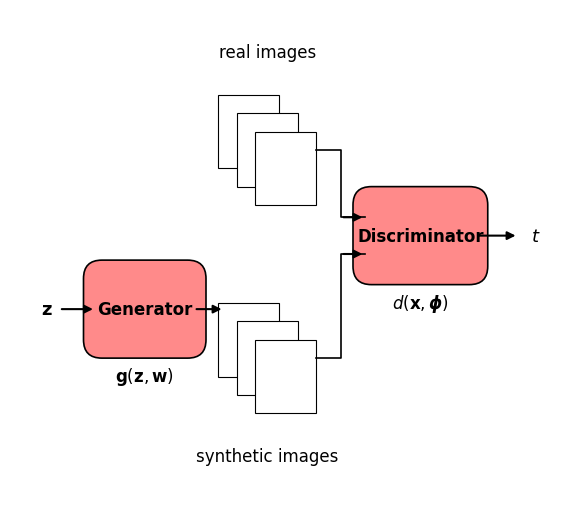

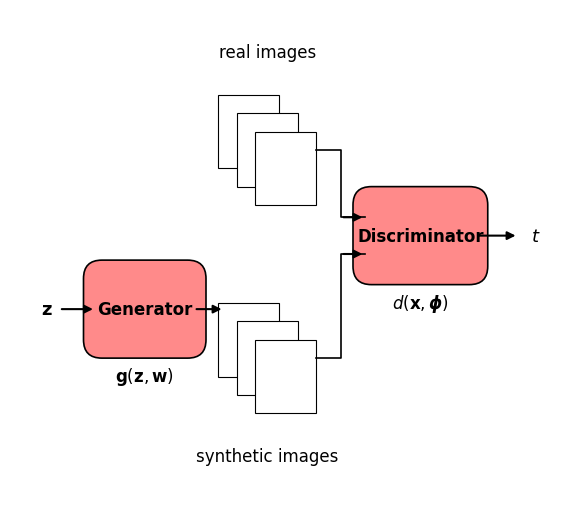

In [3]:
# Figure 17.1 の再現
fig_17_1 = save_and_show(generate_figure_17_1, "fig_17_1_gan_architecture.png")
plt.show()


---
### 17.1.1 損失関数 (Loss Function)

数学的な定式化のため、観測データ点に対して二値目標変数 $t$ を導入します：
$$
t = \begin{cases}
1 & \text{実データ (real data)} \tag{17.2} \\
0 & \text{合成データ (synthetic data)} \tag{17.3}
\end{cases}
$$

識別器ネットワーク $d(\mathbf{x}, \boldsymbol{\phi})$ はロジスティック・シグモイド出力層を持ち、入力 $\mathbf{x}$ が実データである確率を出力します：
$$
P(t = 1 \mid \mathbf{x}) = d(\mathbf{x}, \boldsymbol{\phi}) \tag{17.4}
$$

#### 識別器の交差エントロピー誤差関数
実データと合成データを含む全訓練セットに対する標準的な二値交差エントロピー誤差は次のように定義されます：
$$
E(\mathbf{w}, \boldsymbol{\phi}) = -\frac{1}{N} \sum_{n=1}^N \Big\{ t_n \ln d_n + (1 - t_n) \ln(1 - d_n) \Big\} \tag{17.5}
$$
ここで $d_n = d(\mathbf{x}_n, \boldsymbol{\phi})$ です。

実データ数 $N_{\text{real}}$ と合成データ数 $N_{\text{synth}}$ でそれぞれ正規化すると、全体の GAN 誤差関数 $E_{\text{GAN}}(\mathbf{w}, \boldsymbol{\phi})$ は次のようになります：
$$
E_{\text{GAN}}(\mathbf{w}, \boldsymbol{\phi}) = -\frac{1}{N_{\text{real}}} \sum_{n \in \text{real}} \ln d(\mathbf{x}_n, \boldsymbol{\phi}) - \frac{1}{N_{\text{synth}}} \sum_{n \in \text{synth}} \ln \Big(1 - d(\mathbf{g}(\mathbf{z}_n, \mathbf{w}), \boldsymbol{\phi})\Big) \tag{17.6}
$$

#### ミニマックス対戦と交互勾配更新 (Alternating Gradient Updates)
GAN の学習は**ゼロサムゲーム (Zero-Sum Game)** であり、一方の利益は他方の損失となります：
- **識別器 $\boldsymbol{\phi}$**: 誤差 $E_{\text{GAN}}$ を**最小化**する（本物と偽物を正しく見分ける）
- **生成器 $\mathbf{w}$**: 誤差 $E_{\text{GAN}}$ を**最大化**する（識別器に誤分類させる）

この最適化は、ミニバッチ確率的勾配法を用いて交互にパラメータを更新することで実行されます：
$$
\begin{align}
\Delta \boldsymbol{\phi} &= -\lambda \nabla_{\boldsymbol{\phi}} E_n(\mathbf{w}, \boldsymbol{\phi}) \tag{17.7} \\
\Delta \mathbf{w} &= +\lambda \nabla_{\mathbf{w}} E_n(\mathbf{w}, \boldsymbol{\phi}) \tag{17.8}
\end{align}
$$
式 (17.7) と式 (17.8) で**勾配の符号が逆**になっている点に注意してください。

---

#### 厳密な理論導出: 最適識別器と Jensen-Shannon ダイバージェンス
十分な表現力を持つ任意の識別器関数 $d(\mathbf{x})$ に対し、連続期待値の形で目的関数を記述します：
$$
V(g, d) = \int p_{\text{data}}(\mathbf{x}) \ln d(\mathbf{x}) d\mathbf{x} + \int p_g(\mathbf{x}) \ln(1 - d(\mathbf{x})) d\mathbf{x}
$$
$d(\mathbf{x})$ について被積分関数を各点 $\mathbf{x}$ で最大化（変分微分 $\frac{\delta V}{\delta d(\mathbf{x})} = 0$）すると：
$$
\frac{p_{\text{data}}(\mathbf{x})}{d(\mathbf{x})} - \frac{p_g(\mathbf{x})}{1 - d(\mathbf{x})} = 0
\implies d^*(\mathbf{x}) = \frac{p_{\text{data}}(\mathbf{x})}{p_{\text{data}}(\mathbf{x}) + p_g(\mathbf{x})}
$$
生成器が完全な解に到達したとき ($p_g(\mathbf{x}) = p_{\text{data}}(\mathbf{x})$)、最適識別器はあらゆる点で $d^*(\mathbf{x}) = 0.5$（ランダム推測）となります。

さらに、最適識別器 $d^*(\mathbf{x})$ を目的関数に代入すると：
$$
V(g, d^*) = -\ln 4 + 2 \cdot D_{\text{JS}}(p_{\text{data}} \parallel p_g)
$$
ここで $D_{\text{JS}}$ は **Jensen-Shannon ダイバージェンス** です。
したがって、GAN のミニマックスゲームは大域的最適解において、$p_g$ を $p_{\text{data}}$ に一致させる最適化と厳密に同値になります。

---

#### 条件付き GAN (Conditional GAN: cGAN)
無条件生成 $p(\mathbf{x})$ を、クラスラベルや属性ベクトル $\mathbf{c}$ に条件づけられた生成 $p(\mathbf{x} \mid \mathbf{c})$ に拡張できます（Mirza & Osindero 2014）。
生成器と識別器の双方に $\mathbf{c}$ を追加の入力として与えることで、クラス横断的な特徴表現を共有しながら、指定したクラスの高品質画像を生成することが可能になります。


In [4]:
# 最適識別器 d*(x) と Jensen-Shannon ダイバージェンスの数値検証
x_axis = np.linspace(-5, 5, 500)
dx = x_axis[1] - x_axis[0]

# 2つのガウス分布
p_true = norm.pdf(x_axis, loc=-0.5, scale=1.0)
p_gen = norm.pdf(x_axis, loc=0.5, scale=1.0)

# 最適識別器
d_opt_vals = OptimalDiscriminator.d_star(p_true, p_gen)
jsd_val = OptimalDiscriminator.jensen_shannon_divergence(p_true, p_gen, dx=dx)

print(f"真の分布と生成分布の JSD: {jsd_val:.4f} (nats)")
print(f"分布が一致した時の d*(x): {OptimalDiscriminator.d_star(p_true, p_true)[250]:.4f} (理論値: 0.5)")


真の分布と生成分布の JSD: 0.1114 (nats)
分布が一致した時の d*(x): 0.5000 (理論値: 0.5)


---
### 17.1.2 実践におけるGANの学習 (GAN Training in Practice)

GAN は極めて鮮明で高品質なサンプルを生成できる一方で、敵対的学習特有の不安定性や学習困難性を抱えています：
1. **進捗指標の欠如**: 標準的な最適化と異なり、誤差関数が上下するため、単一の損失値だけでは学習の進捗を監視できない。
2. **モード崩壊 (Mode Collapse)**: 生成器が多様な出力を放棄し、識別器を最も騙しやすい特定の数種類のサンプル（例えば数字 '3' だけ）に写像が集中してしまう現象。

#### 勾配消失問題と識別器の平滑化
学習初期において $p_G$ と $p_{\text{Data}}$ が大きく乖離している場合、識別器 $d(\mathbf{x})$ は容易に完璧な分類器となってしまい、実データ・合成データ双方の近傍で**勾配がほぼゼロ**になります。

#### Figure 17.2: 勾配消失と平滑化識別器
- $p_{\text{Data}}(x)$（赤）と初期の生成分布 $p_G(x)$（青）
- 最適識別器 $d(x)$（実線緑）: 両分布の近傍で平坦になり勾配が消失する
- 平滑化識別器 $\tilde{d}(x)$（破線緑）: 領域全体で有限の勾配を維持し、生成器の更新を加速する


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_17_2_gan_training_difficulty.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/17/result/fig_17_2_gan_training_difficulty.png


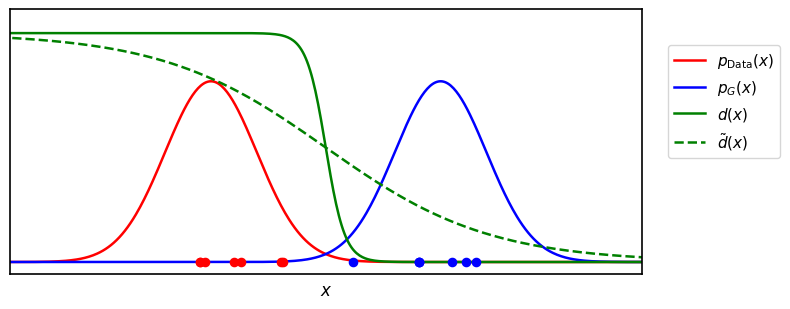

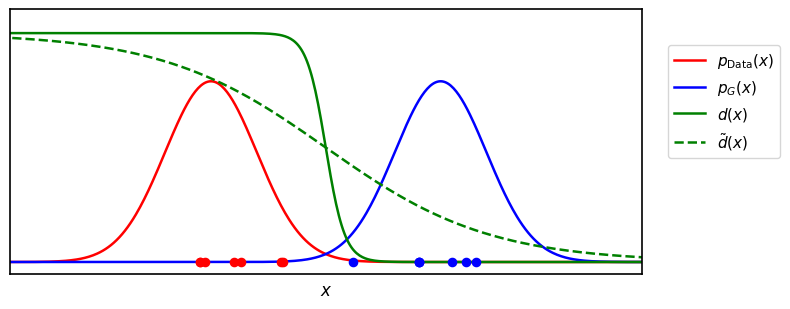

In [5]:
# Figure 17.2 の再現
fig_17_2 = save_and_show(generate_figure_17_2, "fig_17_2_gan_training_difficulty.png")
plt.show()


#### 識別器の平滑化手法
1. **Least-Squares GAN (LSGAN, Mao et al. 2016)**:
   交差エントロピーの代わりに二乗誤差を用い、識別器出力を実数値にすることで飽和を防ぐ：
   $$
   \min_d \frac{1}{2}\mathbb{E}_{\mathbf{x}}[(d(\mathbf{x}) - 1)^2] + \frac{1}{2}\mathbb{E}_{\mathbf{z}}[d(\mathbf{g}(\mathbf{z}))^2]
   $$
2. **インスタンスノイズ (Instance Noise, Sønderby et al. 2016)**:
   実データと合成データ双方に人工的なガウスノイズを付加することで、2つの分布のサポートをオーバーラップさせ、識別器を滑らかにする。

---

#### 非飽和生成器損失 (Non-Saturating Loss)
生成器の元のミニマックス損失項（式 17.6）は、合成画像が偽物と判定される確率を最小化します：
$$
-\frac{1}{N_{\text{synth}}} \sum_{n \in \text{synth}} \ln \Big(1 - d(\mathbf{g}(\mathbf{z}_n, \mathbf{w}), \boldsymbol{\phi})\Big) \tag{17.9}
$$
これに対し、合成画像が本物と判定される確率を最大化する**非飽和損失 (Non-Saturating Loss)** が実用上広く用いられます：
$$
-\frac{1}{N_{\text{synth}}} \sum_{n \in \text{synth}} \ln d(\mathbf{g}(\mathbf{z}_n, \mathbf{w}), \boldsymbol{\phi}) \tag{17.10}
$$

#### Figure 17.3: $-\ln(d)$ と $\ln(1 - d)$ の勾配挙動比較
下図は、横軸 $d \in (0, 1)$ に対する 2 つの関数の挙動を示しています：
- $d \approx 0$（生成器が未熟で識別器に完全に見破られている時）：
  - ミニマックス項 $\ln(1 - d)$ の勾配は極めて平坦（$\frac{d}{dd}\ln(1-d) = -\frac{1}{1-d} \approx -1$）
  - 非飽和項 $-\ln(d)$ の勾配は極めて急峻（$\frac{d}{dd}[-\ln d] = -\frac{1}{d} \to -\infty$）
  これにより、学習初期の生成器に強力な勾配シグナルが供給され、学習が劇的に加速します！


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_17_3_loss_gradients.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/17/result/fig_17_3_loss_gradients.png


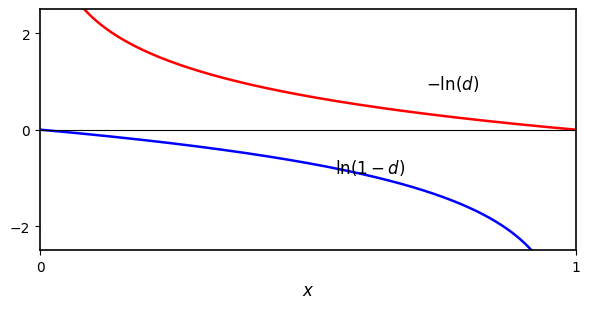

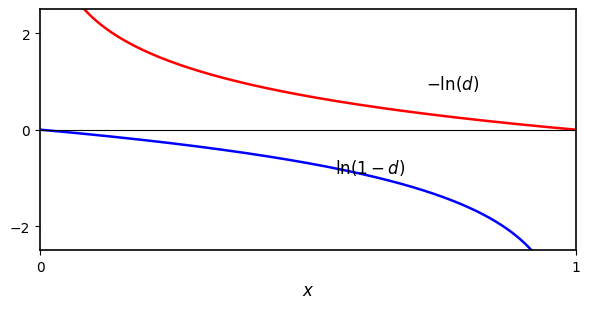

In [6]:
# Figure 17.3 の再現
fig_17_3 = save_and_show(generate_figure_17_3, "fig_17_3_loss_gradients.png")
plt.show()


---
#### ワッサースタイン距離と WGAN-GP (Gulrajani et al. 2017)
分布間の幾何学的距離を測定する指標として、**ワッサースタイン距離 (Wasserstein Distance / Earth Mover's Distance)** があります。
土の山 $p_G$ を $p_{\text{data}}$ に変形するために移動させる「土の量 $\times$ 移動距離」の最小値として定義されます。

WGAN (Arjovsky et al. 2017) では、識別器の勾配にリプシッツ連続性制約を課すことでワッサースタイン距離を最適化します。
さらに **WGAN-GP (Gulrajani et al. 2017)** では、勾配ノルムが 1 に近づくようペナルティを導入します（式 17.11）：
$$
E_{\text{WGAN-GP}}(\mathbf{w}, \boldsymbol{\phi}) = -\frac{1}{N_{\text{real}}} \sum_{n \in \text{real}} \left[ \ln d(\mathbf{x}_n, \boldsymbol{\phi}) - \eta \Big( \|\nabla_{\mathbf{x}_n} d(\mathbf{x}_n, \boldsymbol{\phi})\| - 1 \Big)^2 \right] + \frac{1}{N_{\text{synth}}} \sum_{n \in \text{synth}} \ln d(\mathbf{g}(\mathbf{z}_n, \mathbf{w}), \boldsymbol{\phi}) \tag{17.11}
$$
ここで $\eta$ は勾配ペナルティ項の相対的重みを制御するハイパーパラメータです。


---
## トイモデル実験: 1次元GANによる密度モデリング

1次元ガウス分布 $p_{\text{data}}(x) = \mathcal{N}(2.0, 0.5^2)$ からのサンプルを学習データとし、`Toy1DGAN` を用いて敵対的学習を実行します。
初期状態から学習が進むにつれ、生成器の分布が目標分布に近づいていく様子を可視化します。


300ステップ完了: 最終 Discriminator Loss = 1.3826, Generator Loss = 0.7118


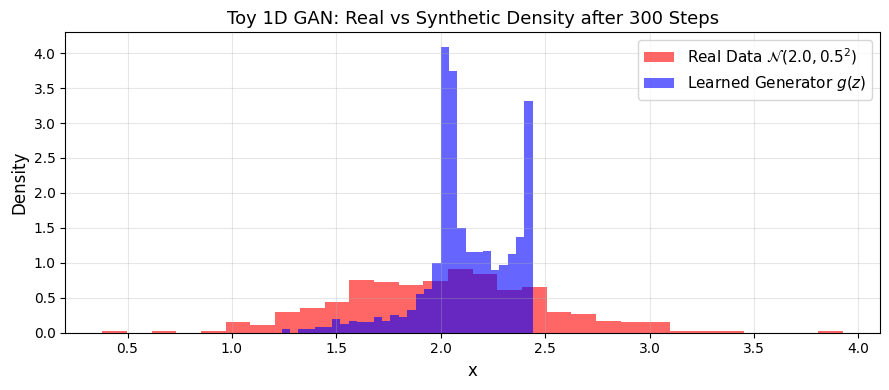

In [7]:
# 1次元 Toy GAN の学習実行
np.random.seed(42)
real_train_data = np.random.normal(loc=2.0, scale=0.5, size=(400, 1))

gan = Toy1DGAN(latent_dim=1, hidden_dim=32, seed=42)

# 学習ループ (非飽和損失)
loss_d_history = []
loss_g_history = []

for step in range(300):
    metrics = gan.train_step(real_train_data, lr=0.03, non_saturating=True)
    loss_d_history.append(metrics["loss_d"])
    loss_g_history.append(metrics["loss_g"])

print(f"300ステップ完了: 最終 Discriminator Loss = {loss_d_history[-1]:.4f}, Generator Loss = {loss_g_history[-1]:.4f}")

# 生成サンプルの分布比較
synthetic_samples = gan.sample_generator(1000)

plt.figure(figsize=(9, 4))
plt.hist(real_train_data, bins=30, density=True, alpha=0.6, color='red', label=r'Real Data $\mathcal{N}(2.0, 0.5^2)$')
plt.hist(synthetic_samples, bins=30, density=True, alpha=0.6, color='blue', label='Learned Generator $g(z)$')
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Toy 1D GAN: Real vs Synthetic Density after 300 Steps', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
### 本節のまとめ

1. **ゼロサムゲームによる尤度回避**:
   GAN は生成器と識別器の対戦を通じて教師なし生成モデリングを二値分類の枠組みで学習し、解析不能な周辺尤度積分の評価を完全に回避する。
2. **大域的最適解と JSD**:
   理想的な識別器のもとで、GAN の最適化は生成分布と実データ分布の間の Jensen-Shannon ダイバージェンスの最小化と厳密に等価になる。
3. **勾配消失への対策**:
   非飽和損失 $-\ln d$、LSGAN、インスタンスノイズ、および WGAN-GP などの洗練された手法により、学習の安定性と勾配供給が大幅に改善された。
